# Decomposição STL

**Etapa:** análise de tendência e sazonalidade

A STL separa a série de treino em tendência, sazonalidade e resíduo para os períodos 5, 20 e 252.

**Entrada:** preço do ouro no trecho de treino  
**Resultado principal:** força sazonal igual a zero nos três períodos avaliados


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. STL e comparação dos períodos

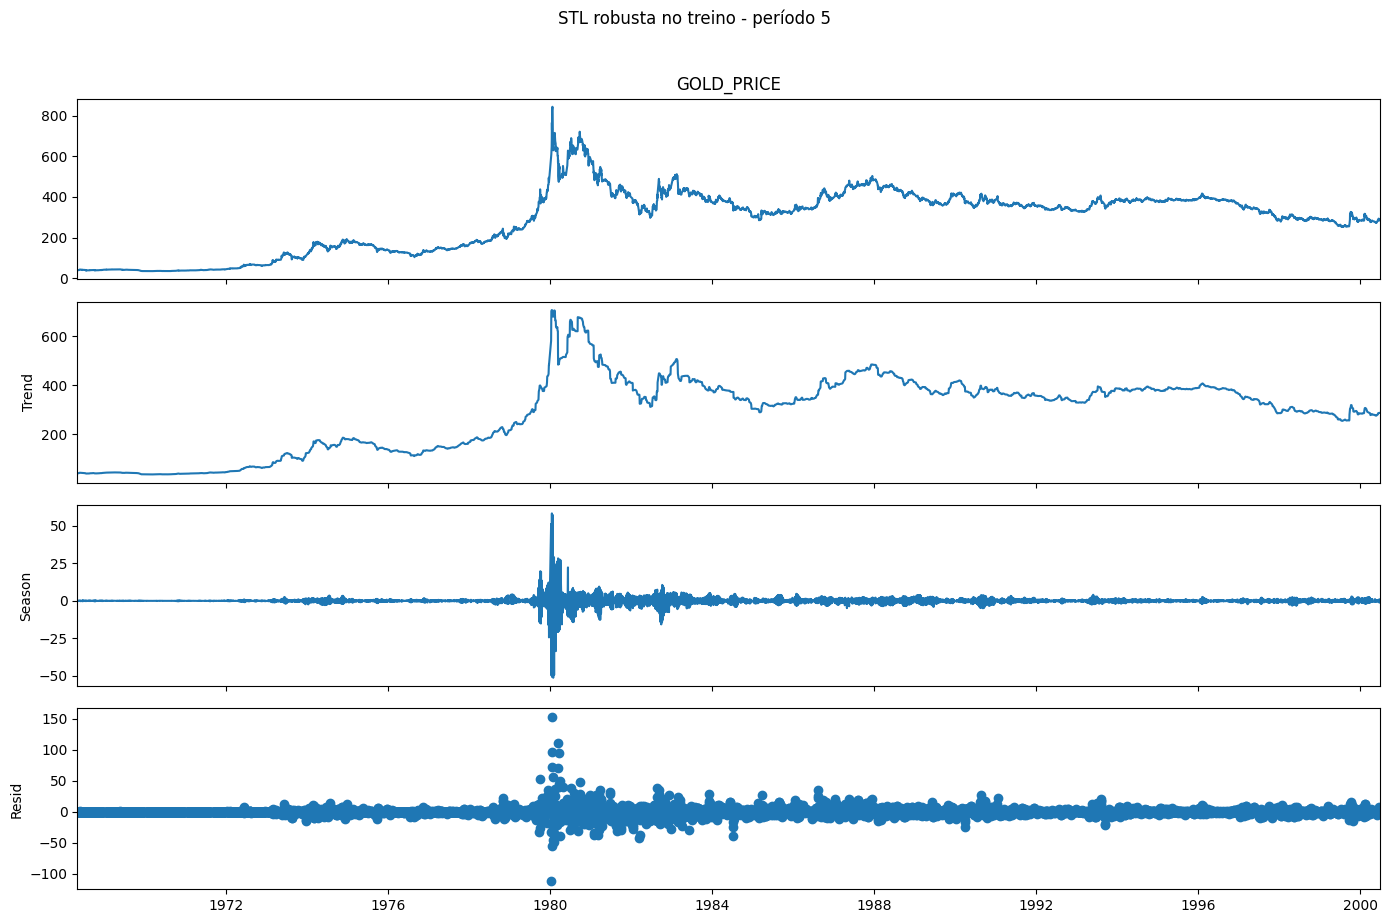

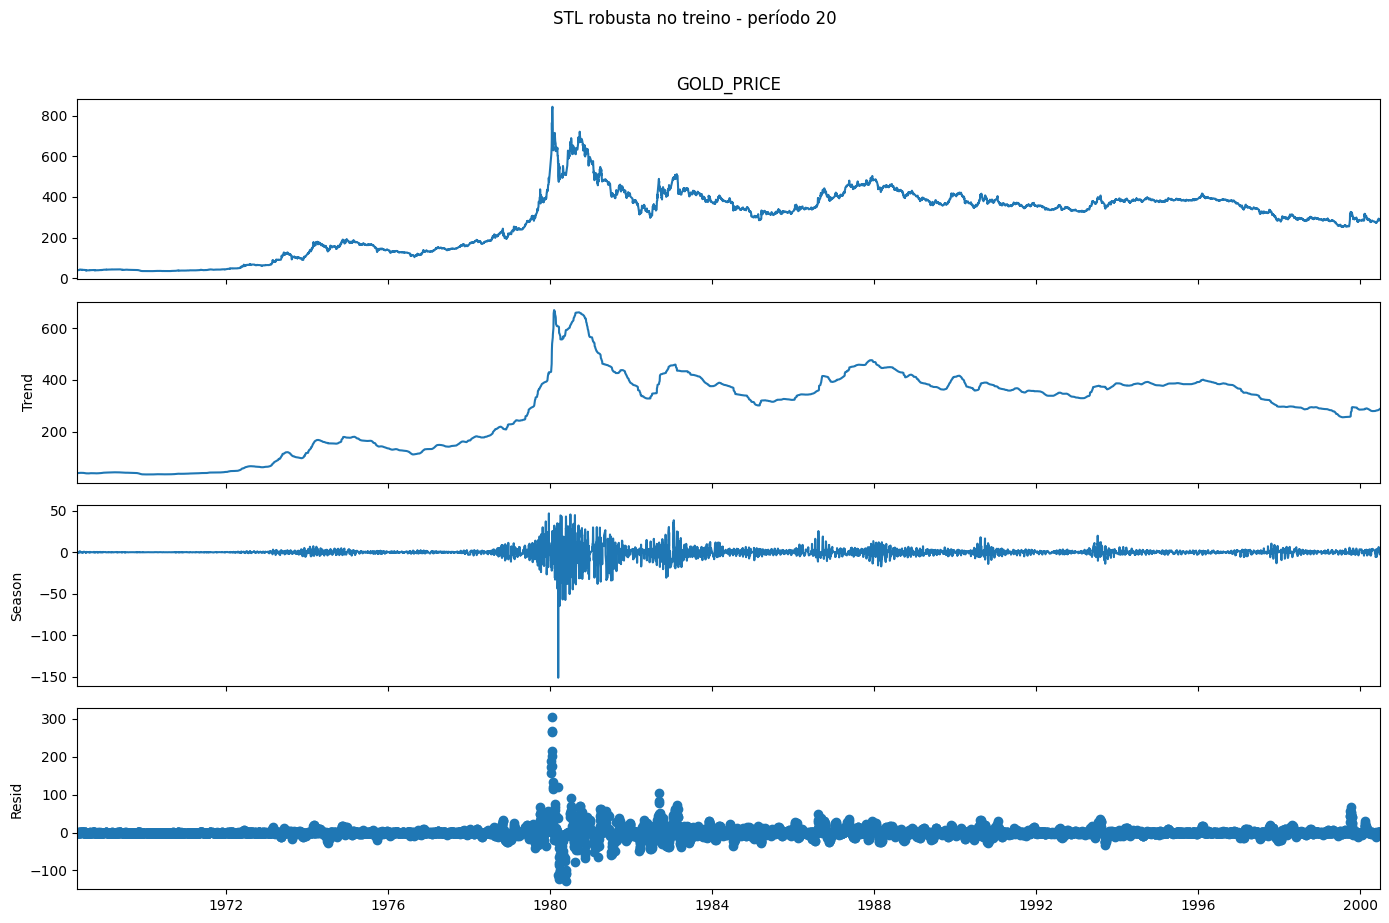

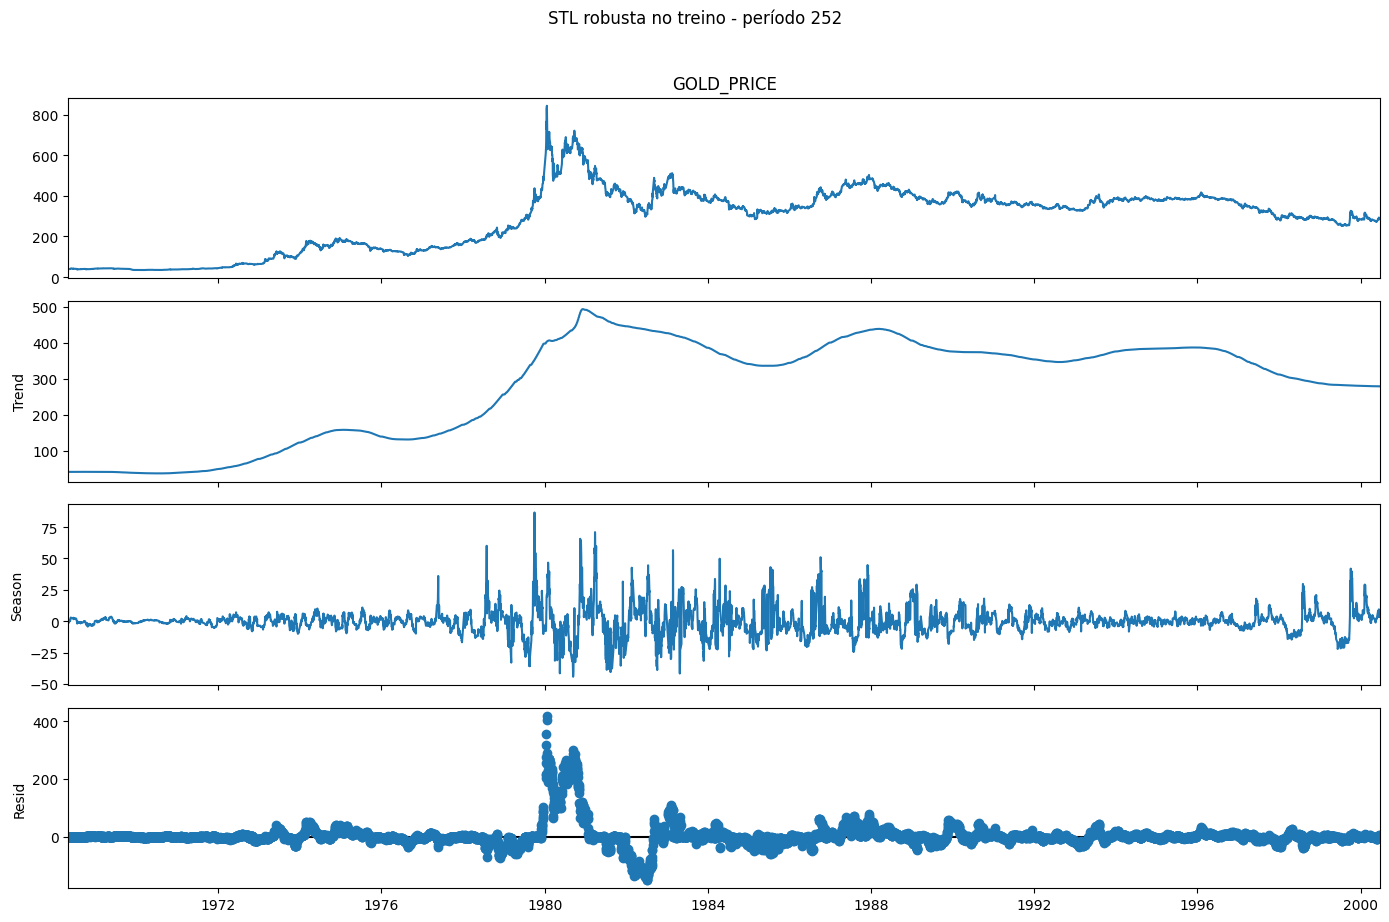

,period,seasonal_strength,trend_strength,residual_std
0,5,0.0,0.9984,6.0593
1,20,0.0,0.9907,14.3810
2,252,0.0,0.9225,41.6081


Text(0.5, 1.0, 'Força sazonal')

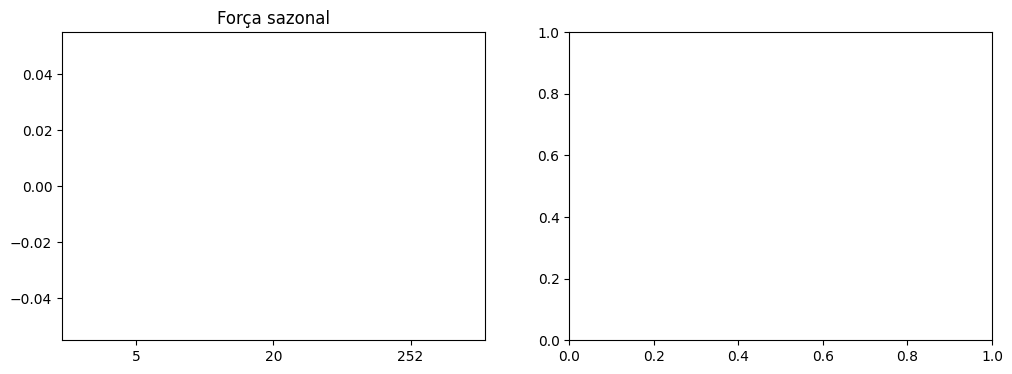

In [3]:
from statsmodels.tsa.seasonal import STL

APPROVED_SEASONAL_PERIOD = 5

df = load_data()
protocol = load_protocol()
train_end = protocol["splits"]["train_end"]
train = df.iloc[:train_end].copy()
y = pd.Series(train["GOLD_PRICE"].to_numpy(), index=train["DATE"], name="GOLD_PRICE")

rows = []
for period in protocol["seasonal_candidates"]:
    result = STL(y, period=period, robust=True).fit()
    residual_variance = np.var(result.resid, ddof=1)
    seasonal_variance = np.var(result.seasonal + result.resid, ddof=1)
    trend_variance = np.var(result.trend + result.resid, ddof=1)
    seasonal_strength = max(0.0, 1 - residual_variance / seasonal_variance)
    trend_strength = max(0.0, 1 - residual_variance / trend_variance)

    rows.append(
        {
            "period": period,
            "seasonal_strength": seasonal_strength,
            "trend_strength": trend_strength,
            "residual_std": result.resid.std(),
        }
    )

    fig = result.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle(f"STL robusta no treino - período {period}", y=1.02)
    fig.tight_layout()
    fig.savefig(OUT / f"stl_period_{period}.png", dpi=150, bbox_inches="tight")
    plt.show()

table = pd.DataFrame(rows).sort_values("period")
display(table.round(4))
table.to_csv(OUT / "stl_candidates.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(table["period"].astype(str), table["seasonal_strength"], color="steelblue")
axes[0].set_title("Força sazonal")


In [4]:
axes[0].set_xlabel("período")
axes[0].set_ylim(0, 1)
axes[1].bar(table["period"].astype(str), table["trend_strength"], color="goldenrod")
axes[1].set_title("Força de tendência")
axes[1].set_xlabel("período")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT / "07_stl_strengths.png", dpi=150, bbox_inches="tight")
plt.show()

if APPROVED_SEASONAL_PERIOD is None:
    raise RuntimeError(
        "DECISÃO NECESSÁRIA: escolha o período sazonal entre 5, 20 e 252."
    )

if APPROVED_SEASONAL_PERIOD not in protocol["seasonal_candidates"]:
    raise ValueError("Período fora dos candidatos analisados.")

protocol["decisions"]["seasonal_period"] = APPROVED_SEASONAL_PERIOD
save_protocol(protocol)
print("Período sazonal aprovado.")

Período sazonal aprovado.


## Interpretação

A tendência é forte, mas não foi encontrada sazonalidade relevante. `m=5` foi mantido apenas como hipótese semanal curta e testável nas grades dos modelos.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/stl_candidates.csv`
- `outputs/stl_period_5.png`
- `outputs/stl_period_20.png`
- `outputs/stl_period_252.png`